# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [2]:
bandit0 = BanditProblem(0)

In [3]:
bandit0.get_num_arms()

3

In [4]:
bandit0.get_reward(arm=0)

1.8255111545554434

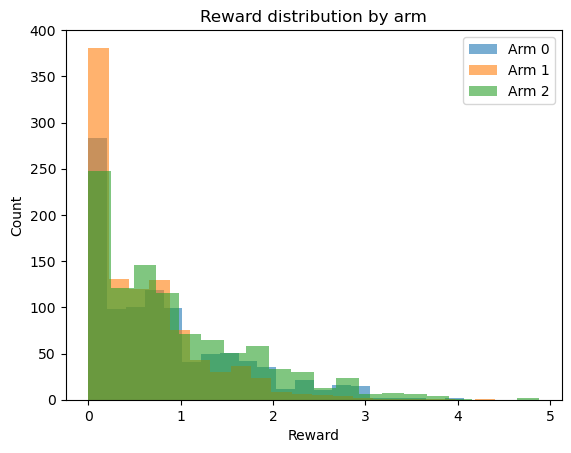

Arm 0: mean = 0.815, std = 0.784
Arm 1: mean = 0.573, std = 0.634
Arm 2: mean = 0.926, std = 0.848


In [6]:
import numpy as np
import matplotlib.pyplot as plt

bandit0 = BanditProblem(0)

samples = {
    arm: [bandit0.get_reward(arm) for _ in range(1000)]
    for arm in range(bandit0.get_num_arms())
}

for arm in range(bandit0.get_num_arms()):
    plt.hist(samples[arm], bins=20, alpha=0.6, label=f"Arm {arm}")

plt.title("Reward distribution by arm")
plt.xlabel("Reward")
plt.ylabel("Count")
plt.legend()
plt.show()

for arm in range(bandit0.get_num_arms()):
    print(f"Arm {arm}: mean = {np.mean(samples[arm]):.3f}, std = {np.std(samples[arm]):.3f}")

Based on the investigation, UCB is the appropriate algorithm because the rewards vary by arm and are noisy, so the algorithm must balance exploring uncertain arms with exploiting the arm that appears best; uniform random wastes pulls and pure greedy ignores uncertainty.


In [14]:
algorithm_choice = (
    "UCB\n"
    "UCB is appropriate because the rewards vary by arm and are noisy, so it balances "
    "exploring uncertain arms with exploiting the arm that appears best, while uniform "
    "random wastes pulls and pure greedy ignores uncertainty.\n"
)

with open('algorithm-choice.txt', 'w') as f:
    f.write(algorithm_choice)

print(algorithm_choice)

UCB
UCB is appropriate because the rewards vary by arm and are noisy, so it balances exploring uncertain arms with exploiting the arm that appears best, while uniform random wastes pulls and pure greedy ignores uncertainty.



## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [9]:
import numpy as np
import pandas as pd

bandit = BanditProblem(2026)

num_arms = bandit.get_num_arms()
counts = np.zeros(num_arms)
values = np.zeros(num_arms)
history = []

for t in range(1, 1001):
    if t <= num_arms:
        arm = t - 1
    else:
        scores = values + np.sqrt(2 * np.log(t) / counts)
        arm = int(np.argmax(scores))

    reward = bandit.get_reward(arm)
    counts[arm] += 1
    prior = values[arm]
    values[arm] = ((prior * (counts[arm] - 1)) + reward) / counts[arm]

    history.append((arm, reward))

history_df = pd.DataFrame(history, columns=["action", "reward"])
history_df.to_csv("history.tsv", sep="\t", index=False)
history_df.head()

,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [10]:
# Build the full history table and save it in the required format.
history_df = pd.DataFrame(history, columns=["action", "reward"])
history_df.to_csv("history.tsv", sep="\t", index=False)
history_df.head()

,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [11]:
# Part 3: Use the action history to estimate each arm's reward distribution.
# Each arm's rewards are the rewards recorded when that arm was chosen.
actions = history_df.groupby('action')['reward']

stats = actions.agg(['min', 'mean', 'max']).reset_index()
stats = stats.rename(columns={
    'action': 'action',
    'min': 'min_reward',
    'mean': 'mean_reward',
    'max': 'max_reward'
})

stats = stats[['action', 'min_reward', 'mean_reward', 'max_reward']]
stats.to_csv('actions.tsv', sep='\t', index=False)
stats

,action,min_reward,mean_reward,max_reward
0,0,0.0,1.216829,6.564312
1,1,0.0,0.166068,0.623193
2,2,0.0,0.125677,0.958464


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [12]:
# Part 4: Estimate regret for several strategies using the action statistics from Part 3.
# The best arm is the one with the highest mean_reward.
mean_rewards = stats.set_index('action')['mean_reward']
best_arm = mean_rewards.idxmax()
best_mean = mean_rewards.max()

rng = np.random.default_rng(2026)

# uniform: choose arms uniformly at random
uniform_regret = 0
for _ in range(1000):
    arm = int(rng.integers(0, len(mean_rewards)))
    uniform_regret += best_mean - mean_rewards.iloc[arm]

# just-i: always pick each fixed arm
just_regrets = []
for arm in range(len(mean_rewards)):
    just_regret = 0
    for _ in range(1000):
        just_regret += best_mean - mean_rewards.iloc[arm]
    just_regrets.append((f'just-{arm}', just_regret))

# actual: use the same UCB strategy from Part 2
# Build regret using recorded action statistics rather than the true rewards.
actual_history = history_df['action'].value_counts().sort_index()
actual_regret = 0
for arm in range(len(mean_rewards)):
    actual_regret += actual_history.get(arm, 0) * (best_mean - mean_rewards.iloc[arm])

strategy_rows = [
    ('uniform', uniform_regret),
    *just_regrets,
    ('actual', actual_regret),
]

strategy_df = pd.DataFrame(strategy_rows, columns=['strategy', 'regret'])
strategy_df.to_csv('strategies.tsv', sep='\t', index=False)
strategy_df

,strategy,regret
0,uniform,707.276095
1,just-0,0.000000
2,just-1,1050.760808
3,just-2,1091.151923
4,actual,22.469888


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [13]:
# Save the strategy comparison results in the required format.
strategy_df = pd.DataFrame(strategy_rows, columns=['strategy', 'regret'])
strategy_df.to_csv('strategies.tsv', sep='\t', index=False)
strategy_df

,strategy,regret
0,uniform,707.276095
1,just-0,0.000000
2,just-1,1050.760808
3,just-2,1091.151923
4,actual,22.469888


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.